# <span style="color:#0b486b">SIT307 - Data Mining and Machine Learning</span>


## <span style="color:#0b486b">Decision Tree</span>

**The purpose of this session is:**

1. use decision tree induction to classify the Titanic dataset


**Instructions** 
In this practical, we look at how to implement decision trees and random forest using sklearn library.

We use the popular Titanic dataset that predicts whether a passenger survived. We use a cleaned up and reduced version of the original dataset. 

1. After you download this notebook, save it as another copy and rename it to `"[yourstudentID]_Week_6_Decision_Tree_Induction.ipynb"`
2. fill in the code cells indicated with your own solution. You can discuss approaches with other students but must only submit your own original solution. 

## <span style="color:#0b486b">Decision trees</span>
Decision tree learning uses a decision tree as a predictive model which maps observations about an item to conclusions about the item's target value. It is one of the predictive modelling approaches used in statistics, data mining and machine learning. Tree models where the target variable can take a finite set of values are called classification trees. In these tree structures, leaves represent class labels and branches represent conjunctions of features that lead to those class labels. Decision trees where the target variable can take continuous values (typically real numbers) are called regression trees. ( -Wikipedia)

Lets start by importing the libraries 

In [1]:
from sklearn import tree
#from sklearn.cross_validation import train_test_split     NOTE:  this has changed to the following
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Our cleaned up dataset is in the data directory:

In [2]:
titanic_df = pd.read_csv("data/Titanic_cleaned_data.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Sex,Age,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,0,1
1,2,1,1,0,38.0,0,0
2,3,1,3,0,26.0,0,1
3,4,1,1,0,35.0,0,1
4,5,0,3,1,35.0,0,1


In this data, the features are:

* Survived: 0=died, 1=survived (response variable)
* Pclass: 1=first class, 2=second class, 3=third class
* Sex: 0=female, 1=male
* Age: numeric value
* Embarked: C or Q or S - binary values for port of embarking.

We now split our data into features (X) and response (y)


In [3]:
# define X and y
feature_cols = ['Pclass', 'Sex', 'Age', 'Embarked_Q', 'Embarked_S']
X = titanic_df[feature_cols]
y = titanic_df.Survived
X

,Pclass,Sex,Age,Embarked_Q,Embarked_S
0,3,1,22.0,0,1
1,1,0,38.0,0,0
2,3,0,26.0,0,1
3,1,0,35.0,0,1
4,3,1,35.0,0,1
...,...,...,...,...,...
886,2,1,27.0,0,1
887,1,0,19.0,0,1
888,3,0,28.0,0,1
889,1,1,26.0,0,0


Lets split the data into 70% training and 30% testing. The random_state argument takes in an integer value. This is for repeatability of results. 

In [4]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

We use the [DecisionTreeClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) in sklearn to fit a decision tree to our data. We specify the maximum depth of the tree to be constructed as 5, initially.

In [5]:
# fit a classification tree with max_depth=5
from sklearn.tree import DecisionTreeClassifier
treeclf = DecisionTreeClassifier(max_depth=5, random_state=1)

# Fit our training data
treeclf.fit(Xtrain, ytrain)

DecisionTreeClassifier(max_depth=5, random_state=1)

Lets look at our training and testing accuracy

In [6]:
print("Training accuracy: {}".format(accuracy_score(ytrain, treeclf.predict(Xtrain))))
print("Testing accuracy : {}".format(accuracy_score(ytest, treeclf.predict(Xtest))))

Training accuracy: 0.8523274478330658
Testing accuracy : 0.7723880597014925


### <span style="color:#0b486b">Impact of tree depth on accuracy</span>

Lets do a 10-fold cross validation to find the average accuracy. We will use the cross_validation library from sklearn to help us with this.

In [7]:
# use crossvalidation to get avg accuracy
#from sklearn.cross_validation import cross_val_score    NOTE:  This has changed to the following
from sklearn.model_selection import cross_val_score
scores = cross_val_score(treeclf, Xtrain, ytrain, cv=10, scoring='accuracy')
print("Accuracy for each fold: {}".format(scores))
print("Mean Accuracy: {}".format(np.mean(scores)))

Accuracy for each fold: [0.74603175 0.79365079 0.85714286 0.87096774 0.79032258 0.75806452
 0.79032258 0.72580645 0.79032258 0.88709677]
Mean Accuracy: 0.8009728622631848


To plot effect of tree-size on accuracy, we build 10 decision trees each with corresponding max_depth = 1,2,3...,10. We do a 10-fold crossvalidation for each tree, and get the mean accuracy.


In [8]:
#from sklearn.learning_curve import validation_curve   NOTE: this has changeed to:
from sklearn.model_selection import validation_curve

# depth takes values from 1 to 10
max_depth_range = range(1, 11)

# do 10-fold cross-validation for each value in max_depth_range and return the accuracy scores. 
train_scores, valid_scores = validation_curve( treeclf, Xtrain, ytrain, param_name="max_depth", param_range=max_depth_range,
    cv=10, scoring="accuracy")


In [9]:
#Size of train_scores will be: length of parameter (max_depth_range) X number of folds
print(train_scores.shape)

(10, 10)


Text(0.5, 1.0, 'Accuracy comparison of training/validation set')

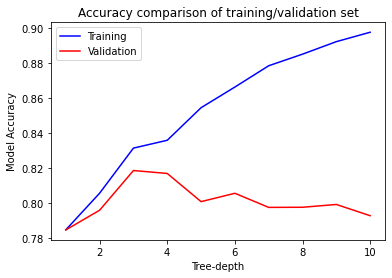

In [10]:
# Mean accuracy score for each value of max-depth
mean_train_score = np.mean(train_scores, axis=1) 
mean_val_score   = np.mean(valid_scores, axis=1)

plt.plot(max_depth_range, mean_train_score, color="blue", linewidth=1.5, label="Training")
plt.plot(max_depth_range, mean_val_score, color="red", linewidth=1.5, label="Validation")
plt.legend(loc="upper left")
plt.xlabel("Tree-depth")
plt.ylabel("Model Accuracy")
plt.title("Accuracy comparison of training/validation set")

From the plot, we can see that as the depth of the tree increases, the decision tree starts to overfit. The best value of max_depth is 3. 

In [11]:
treeclf = DecisionTreeClassifier(max_depth=3)
treeclf.fit(Xtrain,ytrain)
print("Training accuracy: {}".format(accuracy_score(ytrain, treeclf.predict(Xtrain))))
print("Testing accuracy : {}".format(accuracy_score(ytest, treeclf.predict(Xtest))))

Training accuracy: 0.8298555377207063
Testing accuracy : 0.8059701492537313
